In [1]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_excel("Sales_Data.xlsx", sheet_name='Raw_Data')

#Quick Inspection
print('\n-----Shape of the excel file')
print(df.shape)
print('\n-----First 5 rows')
print(df.head())
print(df.info())
print(df.dtypes)
print(df.describe())


-----Shape of the excel file
(150, 11)

-----First 5 rows
   OrderID  OrderDate Region       Category        Product  Quantity  \
0     1001 2024-01-15  North    Electronics         Laptop         3   
1     1002 2024-02-20  South       Clothing        T-Shirt         5   
2     1003 2024-03-12   East  Home & Garden           Sofa         1   
3     1004 2024-04-05   West         Sports  Tennis Racket         2   
4     1005 2024-05-18  North    Electronics          Phone         4   

   UnitPrice  Revenue  Unnamed: 8  Unnamed: 9  Data generated with AI  
0     999.99  2999.97         NaN         NaN                     NaN  
1      19.99    99.95         NaN         NaN                     NaN  
2     499.50   499.50         NaN         NaN                     NaN  
3      89.99   179.98         NaN         NaN                     NaN  
4     699.99  2799.96         NaN         NaN                     NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data

In [11]:
# Revenue by Region (matches your Excel pivot table)
revenue_by_region = df.groupby('Region')['Revenue'].agg(['sum', 'mean', 'count'])
revenue_by_region.columns = ['Total_Revenue', 'Average_Order_Count', 'Total_Orders']
revenue_by_region = revenue_by_region.sort_values(by= 'Total_Revenue', ascending=False)

print('\n--- Revenue by Region---\n')
print(revenue_by_region)


--- Revenue by Region

        Total_Revenue  Average_Order_Count  Total_Orders
Region                                                  
North        89598.84          2357.864211            38
East         14430.55           390.014865            37
South         7526.48           198.065263            38
West          4787.63           129.395405            37


In [13]:
cross_tab = pd.crosstab(
    df['Region'],
    df['Category'],
    values = df['Revenue'],
    aggfunc = 'sum',
    margins = True,
    margins_name = 'Grand_Total'
)

print('\n---- Cross Tabulation-----')
print(cross_tab.round(2))


---- Cross Tabulation-----
Category     Clothing  Electronics  Home & Garden   Sports  Grand_Total
Region                                                                 
East              NaN          NaN       14430.55      NaN     14430.55
North             NaN     89598.84            NaN      NaN     89598.84
South         7526.48          NaN            NaN      NaN      7526.48
West              NaN          NaN            NaN  4787.63      4787.63
Grand_Total   7526.48     89598.84       14430.55  4787.63    116343.50


In [23]:
# Recreating SQL Monthly Trend
monthly_trend = df.groupby(df['OrderDate'].dt.to_period('M'))['Revenue'].agg(['sum', 'mean', 'count'])
monthly_trend.columns = ['Total_Revenue', 'Average_Revenue', 'Total_Orders']
print("\n--- Monthly Revenue ---")
print(monthly_trend)


--- Monthly Revenue ---
           Total_Revenue  Average_Revenue  Total_Orders
OrderDate                                              
2024-01         39149.62      3011.509231            13
2024-02          1762.30       135.561538            13
2024-03          8899.38       684.567692            13
2024-04          2694.71       207.285385            13
2024-05         38719.48      2978.421538            13
2024-06          3544.41       272.646923            13
2024-07          1241.67       103.472500            12
2024-08           808.25        67.354167            12
2024-09         11729.74       977.478333            12
2024-10          2219.77       184.980833            12
2024-11          4289.50       357.458333            12
2024-12          1284.67       107.055833            12


In [24]:
# Build Visualizations
# Chart 1: Revenue by Region (matches your Excel chart)

import matplotlib.pyplot as plt


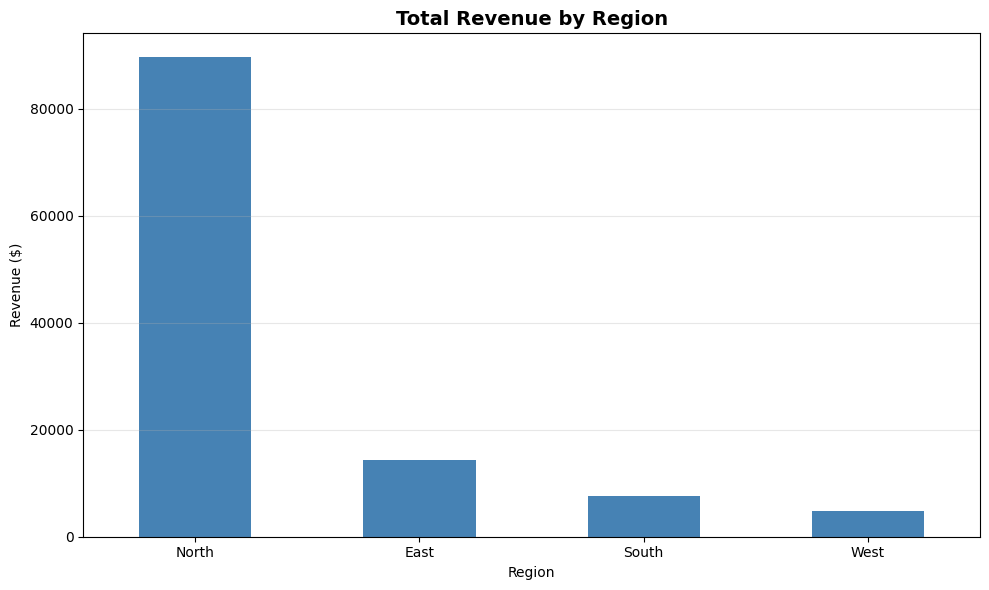

In [27]:
plt.figure(figsize=(10,6))
revenue_by_region['Total_Revenue'].plot(kind='bar', color='steelblue')
plt.title('Total Revenue by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('revenue_by_region.png', dpi=300)
plt.show()


<Figure size 1000x600 with 0 Axes>

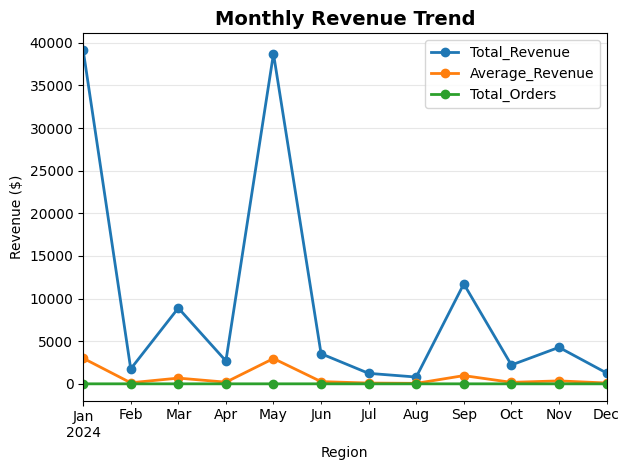

'\n\n'

In [34]:
plt.figure(figsize=(10,6))
monthly_trend.plot(kind='line', marker='o', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300)
plt.show()
'''

'''

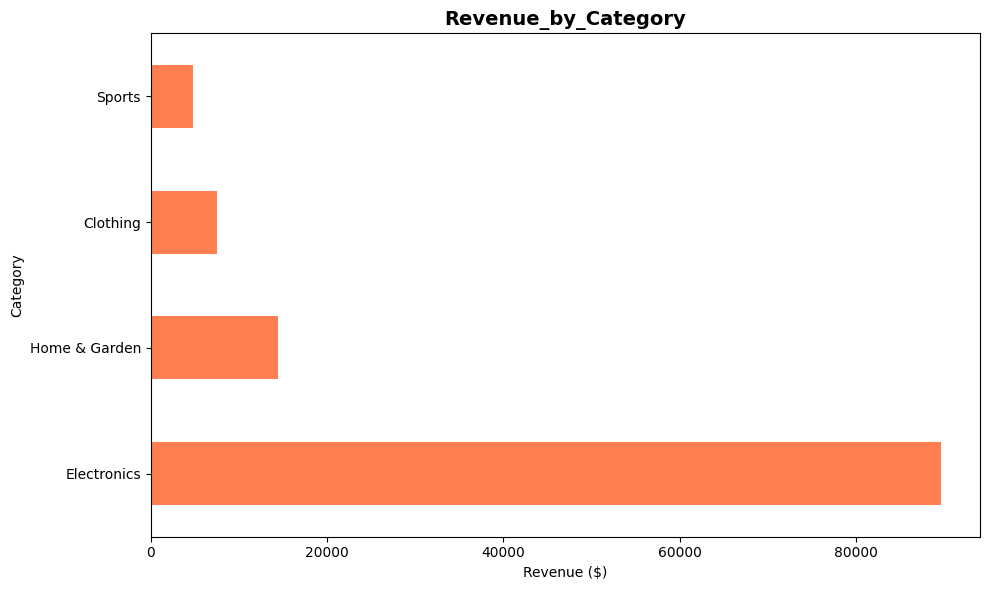

"\nplt.figure(figsize=(10, 6))\ncategory_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)\ncategory_revenue.plot(kind='barh', color='coral')\nplt.title('Revenue by Category', fontsize=14, fontweight='bold')\nplt.xlabel('Revenue ($)')\nplt.tight_layout()\nplt.savefig('revenue_by_category.png', dpi=300)\nplt.show()\n"

In [32]:
# Chart 3: Category Breakdown (new — not in Excel or SQL)
plt.figure(figsize=(10,6))
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
category_revenue.plot(kind='barh', color='coral')
plt.title('Revenue_by_Category', fontsize=14, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('Revenue_by_Category.png', dpi=300)
plt.show()


In [38]:
# Replicating SQL JOIN in Python
# Create the regions DataFrame (equivalent to your SQL regions table)
regions_df = pd.DataFrame({
    'Region': ['North', 'South', 'East', 'West'],
    'Manager': ['Alice Johnson', 'Bob Smith', 'Carol White', 'David Brown'],
    'Target_Revenue': [150000, 120000, 180000, 160000]
})

# Merge with sales data (equivalent to SQL JOIN)
merged = df.groupby('Region')['Revenue'].sum().reset_index()
merged = merged.merge(regions_df, on='Region')

# Calculate performance metrics
merged['Percentage_of_Target'] = round((merged['Revenue'] / merged['Target_Revenue']) * 100, 2)

# Multiple WHEN conditions (equivalent to your SQL CASE)
def performance_status(row):
  if row['Revenue'] >= row['Target_Revenue']:
    return 'Met Target'
  else:
    return 'Target Not Met'

merged['Performance_Status'] = merged.apply(performance_status, axis=1)

print("\n--- Performance vs Target ---")
print(merged[['Region', 'Manager', 'Revenue', 'Target_Revenue', 'Percentage_of_Target', 'Performance_Status']])
'''
print(merged[['Region', 'Manager', 'Revenue', 'Target_Revenue', 'Percentage_of_Target', 'Performance_Status']])
'''


--- Performance vs Target ---
  Region        Manager   Revenue  Target_Revenue  Percentage_of_Target  \
0   East    Carol White  14430.55          180000                  8.02   
1  North  Alice Johnson  89598.84          150000                 59.73   
2  South      Bob Smith   7526.48          120000                  6.27   
3   West    David Brown   4787.63          160000                  2.99   

  Performance_Status  
0     Target Not Met  
1     Target Not Met  
2     Target Not Met  
3     Target Not Met  


"\nprint(merged[['Region', 'Manager', 'Revenue', 'Target_Revenue', 'Percentage_of_Target', 'Performance_Status']])\n"

In [39]:
# Exporting Everything
# Save all results to one Excel file with multiple sheets

with pd.ExcelWriter('Python_Analysis_Result.xlsx') as writer:
  revenue_by_region.to_excel(writer, sheet_name='By_Region')
  cross_tab.to_excel(writer, sheet_name='Cross_Tab')
  monthly_trend.to_excel(writer, sheet_name='Monthly_Trend')
  merged.to_excel(writer, sheet_name='Performance_vs_Target')
  category_revenue.to_excel(writer, sheet_name='By_Category')

print("\n✓ All analysis exported to 'Python_Analysis_Results.xlsx'")


✓ All analysis exported to 'Python_Analysis_Results.xlsx'
